Cluster customers by behaviors, k-means,

Visualize clusters in charts to find what kind of user each cluster represent


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("online_shoppers_intention.csv")

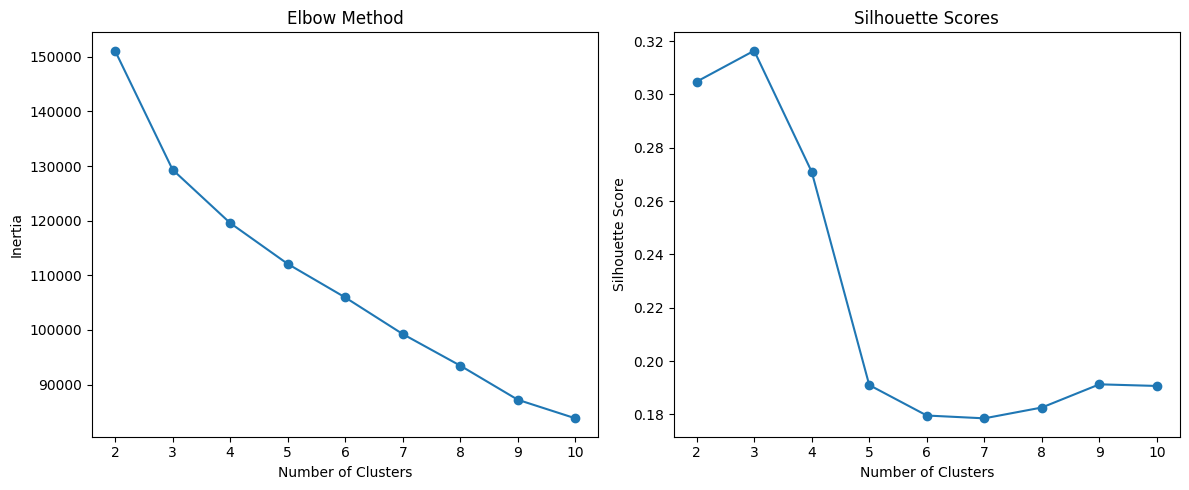

Cluster sizes:
Cluster
0    9653
1    1622
2    1055
Name: count, dtype: int64

Cluster feature means:
         Administrative  Administrative_Duration  Informational  \
Cluster                                                           
0              1.715736                51.333289       0.215891   
1              7.356967               307.941653       2.532676   
2              0.048341                 1.414092       0.016114   

         Informational_Duration  ProductRelated  ProductRelated_Duration  \
Cluster                                                                    
0                      8.143626       23.923133               875.668002   
1                    213.524688       96.839704              3833.992998   
2                      0.092133        3.075829                56.550739   

         BounceRates  ExitRates  PageValues  SpecialDay  OperatingSystems  \
Cluster                                                                     
0           0.009143   0.0

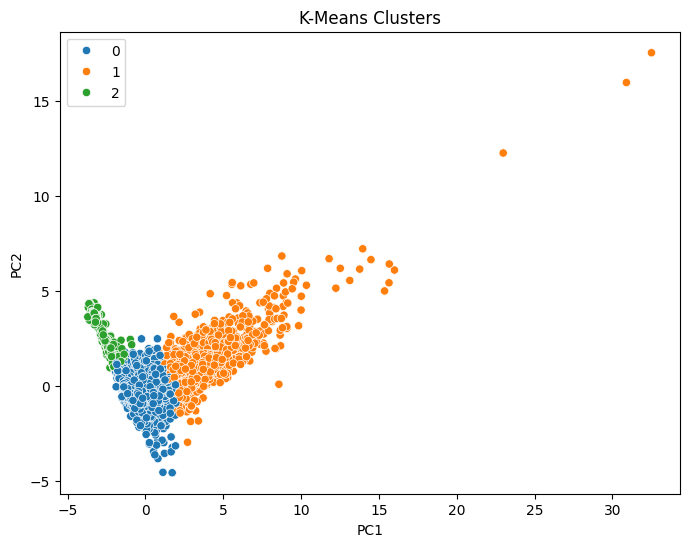

Purchase rate by cluster:
Cluster
0    0.150316
1    0.278052
2    0.005687
Name: Revenue, dtype: float64


In [ ]:
cluster_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]
X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
inertias = []
silhouettes = []
K_values = range(2, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot elbow
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Plot silhouette
plt.subplot(1,2,2)
plt.plot(K_values, silhouettes, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)
cluster_summary = df.groupby("Cluster")[cluster_features].mean()
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_counts)
print("\nCluster feature means:")
print(cluster_summary)


#pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["Cluster"], palette="tab10")
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


#compare behavior
purchase_rate = df.groupby("Cluster")["Revenue"].mean()
print("Purchase rate by cluster:")
print(purchase_rate)


In [ ]:
"""

k=3
silhouette score = 0.32(highest) - how well seperated and well formed the clusters are, higher = better
0.2-0.4 is acceptable for real world cusomter behavioral data bc user behavior overlaps heavily, customers dont fall into clean groups, people online unpredictable,
most features have a wide range, no real "boundary" between the types of visitors



Cluster 0: normal browers
-moderate pages visited
-moderate durations
-moderate bounce/exit
-purchase rate 15.03%

Cluster 1: Highly engaged buyers
-very large product page volume
-very long session duration
-high page value
-27.80% purchase rate



Cluster 2:Quick Exits/accidental visitors
-very few pages
-extremely short durations
-very high bounce rate
-purchase rate 0.5%


-what doe each cluster represent?
- how to target each group?
-differences in purchase liklihood
-real world interpretability


conclusion:
clusters are meaningful, can explain behavioral differences, differ in purchase rates,


------------------------------------------------------------------------------------------------------------------------------------------------------------------------


predictive model + clsuters
send the right interventions (ads, promotions, personalization) to right type of customer at the right time.



cluster 1:  high engagement, page view, timee spent, already want to buy
-these people dont need ads/promotions, already likely to purchase
real world interpretation:
-dont waste money/budget showing ads to them
-instead show upsells or premium items, because they are high-value customers, if they dont wnat to buy it, its okay because they are already buying something else

Cluster 0: average behavior, medium engagment, moderate purchase liklihood
real world interpretation:
-these people are persudable, they may buy something with a push or a nudge
-ideal group to sell ads or small incentives to (free shipping, discount for next purchase, retargeting ad, cart reminder)
-ads here have a good chance of lifting revenue


Cluster 2: high bounce rate, only 1-3 page clicks, abs
-this group is unlikely to buy something, even with ads
real world interpretation:
-avoid spending budget/money on them
-maybe only show (super-light ads, homepage redesign improvements, personalized recommendations)



predictive model use to target individuals inside these groups
-high prob(>0.7) - will buy anyways, no ads
-low prob(<0.2) - unlikely to purchase, ads wont help much
-middle range(0.2-0.6) - these people are pursuadeable



Combine Cluster + preditive model
Cluster 1(highly engaged) and  high model prediction: dont send ads, maybe show upsells/premium items.
Reason: saves budget, show possible item to sell, they will purchase their item anyways


Cluster 0(medium purchase possibility) and middle range prediction: send ads/promotions
Reason: this increases the revenue the most


Cluster 2(high exit rate) and low prediction: dont send any costly ads, small ads
Reason: unlikely to buy anything, ads wasteful ressources and money


Cluster 0(average/medium users and purchase possbility) and  high prediction: dont send ads
Reason: already buying item
-Even if customer isnt brower heavy, is still predicted to purcchase an item, therefore no need to spend budget




By combining a predictive model with behavioral clustering, we can identify which customers are likely to purchase organically
and which have mid-range purchase probability. Focusing promotional spending on “persuadable” customers in Cluster 0 with moderate
predicted purchase likelihood maximizes return on ad spend and increases revenue.

"""

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=cluster_features
)
loadings

,PC1,PC2
Administrative,0.381342,0.054003
Administrative_Duration,0.327967,0.108310
Informational,0.347082,0.280534
Informational_Duration,0.295201,0.302496
ProductRelated,0.410660,0.149917
ProductRelated_Duration,0.412413,0.190580
BounceRates,-0.278886,0.605020
ExitRates,-0.324821,0.575150
PageValues,0.092753,-0.184932
SpecialDay,-0.071747,0.107437


In [ ]:
#pc1 positive values -user engagment and browsing depth
ProductRelated
ProductRelated_Duration
Administrative
Administrative_Duration
Informational
Informational_Duration
--
Those with high PC1 values(These are committed shoppers.):
-view lots of pages
-browse product pages deeply
-read info/administrative content
-stay longer in sessions


Those with low PC1 values(These are weakly engaged visitors.):
-view few pages
-short sessions
-minimal exploration




#pc2 postitives
BounceRates
ExitRates
-PC2 represents Likelihood of abandoning the session or shopping disinterest

High PC2:
-bounces quickly
-exits early
-likely just browsing + not buying

Low PC2:
-NOT bouncing
-staying longer
-possibly engaged

PageValues is negative in PC2 (-0.1849)
Meaning: High PC2 = low PageValues
(not looking at pages that lead to purchases)


----
Pc1 = Engagement Depth / Shopping Effort
Pc2 = Bounce vs Commitment / Intent Strength



CLuster 1:High engagement, low bounce (likely high PC1 low PC2)
Long session durations
Lots of page views
Low bounce
High purchase rate: 27.8%
Interpretation: These are serious shoppers. They’re likely to buy.


Cluster 2: Low engagement, high bounce
Short sessions
Almost zero page views
High bounce
Purchase rate: 0.56%
Interpretation:These are uninterested visitors / accidental clicks / bots / window shoppers.

Cluster 0:Moderate engagement, moderate bounce
Medium browsing
Medium purchase rate: 15.0%
Interpretation:These are casually interested shoppers.



ad recommendation:
cluster 1 (engaged / high intent)
DO NOT waste ads
Already buying
Instead give:
upselling
product accessories
recommendations
cross-selling
Goal: increase order value, not conversion

Cluster 2 (disinterested / high bounce)
Send strong promotions or ads
High discounts
Promo codes
Newsletter capture
Retargeting ads
Goal: convert non-buyers into buyers

Cluster 0 (moderate)
Light promo or reminder help
Maybe a 10% discount
Gentle nudge
Goal: move them toward stronger commitment